In [1]:
from pathlib import Path
import geopandas as gpd
import pandas as pd

# SMART-DS grid geometry: set a subregion here to avoid loading the full location.
location_name = Path("..").resolve().name
root = Path("../data/smart_ds/2016")
selected_subregion = None  # Set to a subregion folder name to load less data; None loads all subregions.
path_pattern = "*/scenarios/base_timeseries/geojson/*.json" if selected_subregion is None else f"{selected_subregion}/scenarios/base_timeseries/geojson/*.json"
paths = sorted(root.glob(path_pattern))
if not paths:
    available = ", ".join(sorted(path.name for path in root.iterdir() if path.is_dir())) if root.exists() else "none"
    raise FileNotFoundError(f"No SMART-DS GeoJSON files found for selected_subregion={selected_subregion!r}. Available subregions: {available}")

def read_smartds_grid(path):
    return gpd.read_file(path, columns=["type", "geometry"]).assign(subregion=path.parts[-5], feeder=path.stem)

grid = pd.concat([read_smartds_grid(path) for path in paths], ignore_index=True)
ax = grid[grid["type"].eq("Line")].plot(figsize=(9, 9), linewidth=0.25, color="tab:blue", alpha=0.55)
grid[~grid["type"].eq("Line")].plot(ax=ax, markersize=0.15, color="black", alpha=0.25)
subregion_label = "all subregions" if selected_subregion is None else selected_subregion
ax.set_title(f"SMART-DS {location_name.title()} {subregion_label} base grid ({len(paths)} feeders)")
ax.set_axis_off()


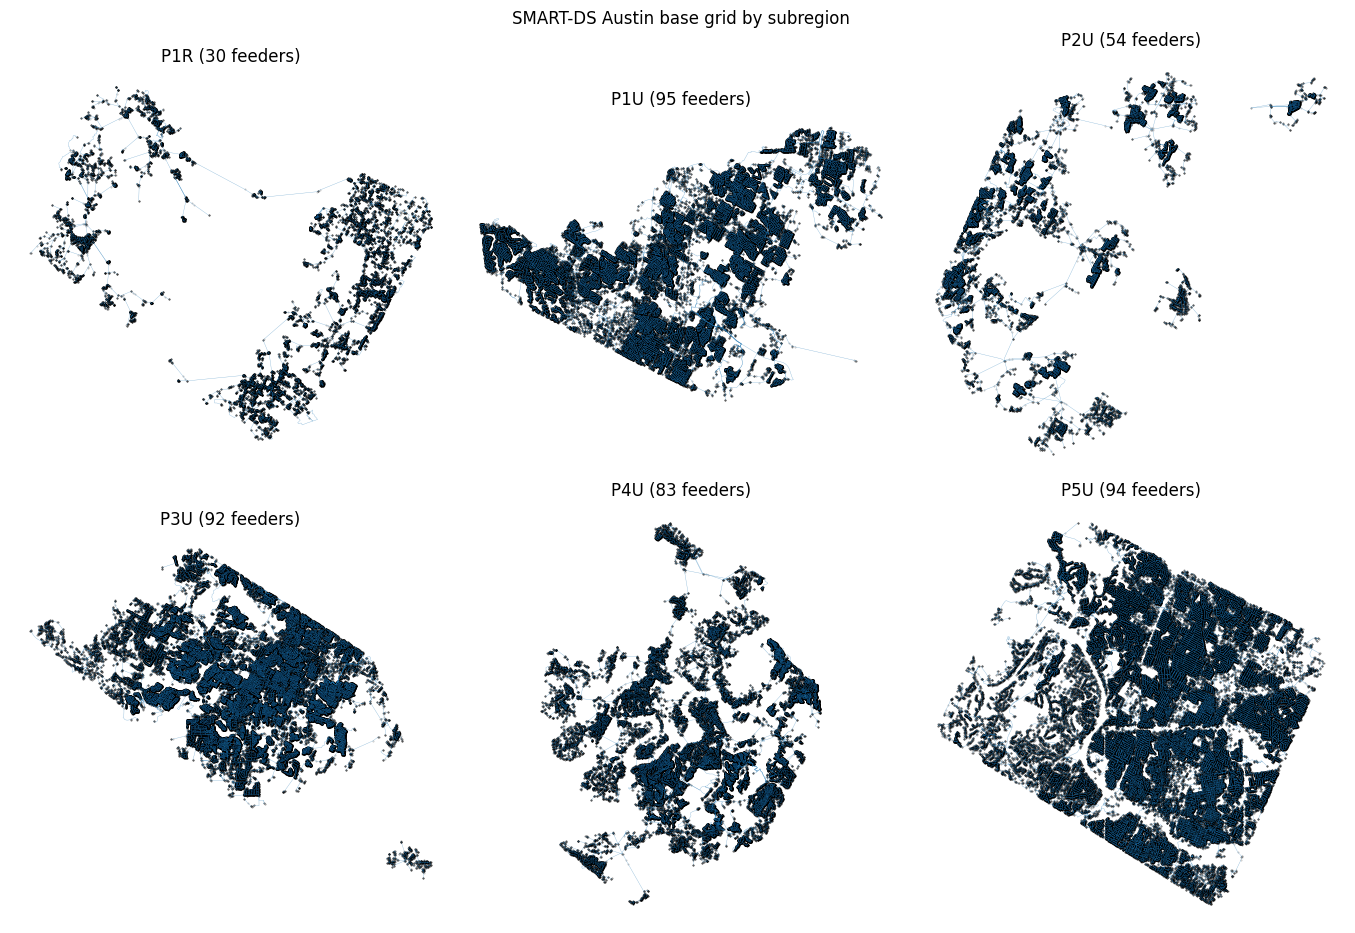

In [2]:
import math
import matplotlib.pyplot as plt

def plot_smartds_subregions(grid, *, ncols=3, line_width=0.25, node_size=0.15):
    subregions = sorted(grid["subregion"].dropna().unique())
    nrows = math.ceil(len(subregions) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.5 * nrows), constrained_layout=True)
    axes = list(axes.ravel())

    for ax, subregion in zip(axes, subregions):
        subset = grid[grid["subregion"].eq(subregion)]
        lines = subset[subset["type"].eq("Line")]
        points = subset[~subset["type"].eq("Line")]
        lines.plot(ax=ax, linewidth=line_width, color="tab:blue", alpha=0.55)
        points.plot(ax=ax, markersize=node_size, color="black", alpha=0.25)
        ax.set_title(f"{subregion} ({subset['feeder'].nunique()} feeders)")
        ax.set_axis_off()

    for ax in axes[len(subregions):]:
        ax.set_axis_off()

    fig.suptitle(f"SMART-DS {location_name.title()} base grid by subregion", y=1.02)
    return fig, axes[:len(subregions)]

fig, axes = plot_smartds_subregions(grid)